# Gauge-induced excess broadcast error

This notebook reuses the numerical results from the gauge-sensitivity notebook and isolates the avoidable representation-dependent component of rank-constrained broadcast error:

$$\Delta E_{r,j}^{\mathrm{method}}=E_{r,j}^{\mathrm{method}}-E_r^*.$$

A value of zero means that the broadcast reaches the dense rank-$r$ optimum. Positive values measure error beyond the unavoidable rank constraint. The analysis concerns broadcast representation only; it does not claim that SP+ eliminates LoRA gauge freedom or repairs aggregation-stage semantic mismatch.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import font_manager
from matplotlib.lines import Line2D

TOL = 1e-10
cwd = Path.cwd().resolve()
if cwd.name == "gauge_induced_excess_error":
    OUTPUT_DIR = cwd
    FIGURES_ROOT = cwd.parent
else:
    FIGURES_ROOT = cwd / "rbla+" / "figures"
    OUTPUT_DIR = FIGURES_ROOT / "gauge_induced_excess_error"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SOURCE_CSV = FIGURES_ROOT / "gauge_sensitivity" / "gauge_sensitivity_results.csv"

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
paper_font = "Times New Roman" if "Times New Roman" in available_fonts else "DejaVu Serif"
mpl.rcParams.update({
    "font.family": paper_font,
    "font.size": 8,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.45,
    "lines.markersize": 4.2,
    "grid.color": "0.75",
    "grid.linestyle": ":",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.55,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

print(f"Source: {SOURCE_CSV}")
print(f"Output directory: {OUTPUT_DIR}")

Source: H:\paper-experiment-record\rbla+\figures\gauge_sensitivity\gauge_sensitivity_results.csv
Output directory: H:\paper-experiment-record\rbla+\figures\gauge_induced_excess_error


In [2]:
required_columns = {
    "gauge_type", "trial", "R", "r", "method", "broadcast_error",
    "dense_optimal_error", "full_update_error", "numerical_checks_passed",
}
if not SOURCE_CSV.is_file():
    raise FileNotFoundError(f"Run the source gauge notebook first: {SOURCE_CSV}")

results = pd.read_csv(SOURCE_CSV)
missing = required_columns.difference(results.columns)
if missing:
    raise ValueError(f"Source CSV is missing columns: {sorted(missing)}")

results["excess_error"] = results["broadcast_error"] - results["dense_optimal_error"]
results["reference_method"] = "Dense truncated SVD optimum"
results["source_results"] = "../gauge_sensitivity/gauge_sensitivity_results.csv"

ranks = sorted(results["r"].unique().astype(int).tolist())
maximum_rank = int(results["R"].max())
rbla = results[results["method"] == "RBLA prefix"].copy()
sp_plus = results[results["method"] == "SP+ (compact QR)"].copy()

gauge_stats = (
    rbla.groupby(["gauge_type", "r"])["excess_error"]
    .agg(
        median="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        mean="mean",
        std="std",
        minimum="min",
        maximum="max",
    )
    .reset_index()
)
sp_stats = (
    sp_plus.groupby("r")["excess_error"]
    .agg(median="median", q25=lambda values: values.quantile(0.25),
         q75=lambda values: values.quantile(0.75), maximum_absolute=lambda values: np.abs(values).max())
    .reset_index()
)

source_checks_passed = bool(
    (results["numerical_checks_passed"].astype(str).str.lower() == "true").all()
)
diagonal_excess = rbla.loc[rbla["gauge_type"] == "diagonal", "excess_error"]
full_rank_excess = results.loc[results["r"] == maximum_rank, "excess_error"]
checks = {
    "source gauge experiment passed its numerical checks": source_checks_passed,
    "all analysis values are finite": bool(np.isfinite(results["excess_error"]).all()),
    "excess errors are non-negative within tolerance": bool(results["excess_error"].min() >= -TOL),
    "SP+ excess error is numerical zero": bool(sp_plus["excess_error"].abs().max() <= TOL),
    "diagonal RBLA is a zero-excess negative control": bool(diagonal_excess.abs().max() <= TOL),
    "full-rank excess error is numerical zero": bool(full_rank_excess.abs().max() <= TOL),
}
all_checks_passed = all(checks.values())
results["analysis_checks_passed"] = all_checks_passed

csv_path = OUTPUT_DIR / "gauge_induced_excess_error.csv"
results.to_csv(csv_path, index=False, float_format="%.16e")
check_table = pd.DataFrame({"check": checks.keys(), "passed": checks.values()})
display(check_table)
assert all_checks_passed, check_table.loc[~check_table["passed"], "check"].tolist()
print(f"Loaded {len(results):,} rows covering ranks {ranks}")
print(f"Saved analysis data to {csv_path.name}")

,check,passed
0,source gauge experiment passed its numerical c...,True
1,all analysis values are finite,True
2,excess errors are non-negative within tolerance,True
3,SP+ excess error is numerical zero,True
4,diagonal RBLA is a zero-excess negative control,True
5,full-rank excess error is numerical zero,True


Loaded 9,600 rows covering ranks [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Saved analysis data to gauge_induced_excess_error.csv


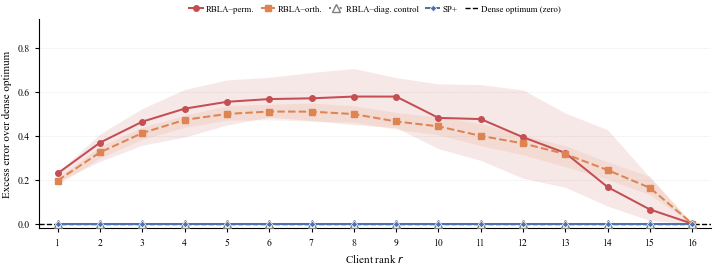

Saved vector figure to gauge_induced_excess_error.pdf


In [3]:
gauge_order = ("permutation", "orthogonal", "diagonal")
styles = {
    "permutation": dict(color="#C44E52", linestyle="-", marker="o", label="RBLA–perm."),
    "orthogonal": dict(color="#DD8452", linestyle="--", marker="s", label="RBLA–orth."),
    "diagonal": dict(color="#7F7F7F", linestyle=":", marker="^", label="RBLA–diag. control"),
}

fig, ax = plt.subplots(figsize=(7.16, 2.70))
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0, zorder=1)

for gauge_type in gauge_order:
    group = gauge_stats[gauge_stats["gauge_type"] == gauge_type].sort_values("r")
    x = group["r"].to_numpy(dtype=float)
    median = group["median"].to_numpy(dtype=float)
    q25 = group["q25"].to_numpy(dtype=float)
    q75 = group["q75"].to_numpy(dtype=float)
    style = styles[gauge_type]
    if gauge_type != "diagonal":
        ax.fill_between(x, q25, q75, color=style["color"], alpha=0.13, linewidth=0, zorder=2)
    marker_face = "white" if gauge_type == "diagonal" else style["color"]
    marker_size = 5.2 if gauge_type == "diagonal" else 4.0
    ax.plot(
        x, median, color=style["color"], linestyle=style["linestyle"],
        marker=style["marker"], markerfacecolor=marker_face,
        markeredgecolor=style["color"], markersize=marker_size,
        label=style["label"], zorder=3,
    )

sp_group = sp_stats.sort_values("r")
ax.plot(
    sp_group["r"], sp_group["median"], color="#4C72B0", linestyle="-",
    marker="D", markersize=3.3, markerfacecolor="#4C72B0",
    markeredgecolor="white", markeredgewidth=0.45,
    label="SP+", zorder=5,
)

ax.set_xlabel(r"Client rank $r$")
ax.set_ylabel("Excess error over dense optimum")
ax.set_xticks(ranks)
ax.set_xlim(min(ranks) - 0.45, max(ranks) + 0.45)
maximum_excess = float(rbla["excess_error"].max())
ax.set_ylim(-0.025 * maximum_excess, 1.08 * maximum_excess)
ax.grid(True, axis="y", which="major")
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", width=0.8, length=3)

legend_handles, legend_labels = ax.get_legend_handles_labels()
legend_handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=1.0))
legend_labels.append("Dense optimum (zero)")
ax.legend(
    legend_handles, legend_labels,
    loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=5,
    fontsize=6.4, handlelength=1.5, handletextpad=0.35,
    columnspacing=0.8, borderaxespad=0.0,
)
fig.tight_layout(pad=0.3)

pdf_path = OUTPUT_DIR / "gauge_induced_excess_error.pdf"
fig.savefig(pdf_path)
plt.show()
print(f"Saved vector figure to {pdf_path.name}")

In [4]:
display(gauge_stats)

positive_types = rbla[rbla["gauge_type"].isin(["permutation", "orthogonal"])]
median_by_type_rank = positive_types.groupby(["gauge_type", "r"])["excess_error"].median()
largest_index = median_by_type_rank.idxmax()
largest_value = float(median_by_type_rank.max())

print("Gauge-induced excess-error summary")
print(f"  source rows: {len(results):,}; R={maximum_rank}; ranks={ranks}")
print(f"  largest median non-diagonal excess: {largest_value:.6e} "
      f"({largest_index[0]}, r={largest_index[1]})")
print(f"  maximum absolute SP+ excess: {sp_plus['excess_error'].abs().max():.3e}")
print(f"  maximum absolute diagonal-control excess: {diagonal_excess.abs().max():.3e}")
print(f"  all analysis checks passed: {all_checks_passed}")
print("  interpretation: positive RBLA excess under non-diagonal gauges measures")
print("  representation-dependent broadcast penalty beyond the unavoidable rank")
print("  constraint. SP+ remains at the dense optimum to numerical precision.")

,gauge_type,r,median,q25,q75,mean,std,minimum,maximum
0,diagonal,1,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,diagonal,2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,diagonal,3,5.551115e-17,0.000000e+00,5.551115e-17,4.052314e-17,2.476886e-17,0.000000e+00,5.551115e-17
3,diagonal,4,-1.110223e-16,-1.110223e-16,-1.110223e-16,-1.110223e-16,0.000000e+00,-1.110223e-16,-1.110223e-16
4,diagonal,5,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,diagonal,6,0.000000e+00,0.000000e+00,0.000000e+00,8.326673e-19,4.758599e-18,0.000000e+00,2.775558e-17
6,diagonal,7,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,diagonal,8,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,diagonal,9,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,diagonal,10,-1.387779e-17,-1.387779e-17,-1.387779e-17,-1.373901e-17,1.387779e-18,-1.387779e-17,0.000000e+00


Gauge-induced excess-error summary
  source rows: 9,600; R=16; ranks=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  largest median non-diagonal excess: 5.785762e-01 (permutation, r=8)
  maximum absolute SP+ excess: 1.733e-15
  maximum absolute diagonal-control excess: 1.381e-15
  all analysis checks passed: True
  interpretation: positive RBLA excess under non-diagonal gauges measures
  representation-dependent broadcast penalty beyond the unavoidable rank
  constraint. SP+ remains at the dense optimum to numerical precision.
